================ EDA ================
1. Información general del archivo:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  str    
 3   Tumor_Type           20000 non-null  str    
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  str    
 6   Histology            20000 non-null  str    
 7   Stage                20000 non-null  str    
 8   Symptom_1            20000 non-null  str    
 9   Symptom_2            20000 non-null  str    
 10  Symptom_3            20000 non-null  str    
 11  Radiation_Treatment  20000 non-null  str    
 12  Surgery_Performed    20000 non-null  str    
 13  Chemotherapy         20000 non-null  str    
 14  Survival_Rate        20

C:\Users\aayal\AppData\Local\Temp\ipykernel_33448\759355564.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=columna_objetivo, data=df, palette='viridis')


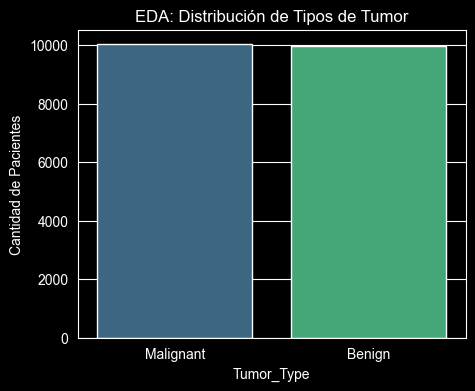


Iniciando Optimización Bayesiana...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from skopt import BayesSearchCV
from skopt.space import Real
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve, auc

# 1. Cargar Datos y Análisis Exploratorio (EDA)

print("================ EDA ================")
df = pd.read_csv('brain_tumor_dataset.csv')
columna_objetivo = 'Tumor_Type'

print("1. Información general del archivo:")
df.info()

print("\n2. Conteo de valores nulos o vacíos:")
print(df.isnull().sum())

plt.figure(figsize=(5, 4))
sns.countplot(x=columna_objetivo, data=df, palette='viridis')
plt.title('EDA: Distribución de Tipos de Tumor')
plt.ylabel('Cantidad de Pacientes')
plt.show()
print("=====================================\n")


# 2. Preprocesamiento de Datos

X = df.drop(['Patient_ID', columna_objetivo], axis=1)
y = df[columna_objetivo]

X = pd.get_dummies(X, drop_first=True)
y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos (Crucial para SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Optimización Bayesiana (10 Folds y AUC)

modelo = SVC(kernel='linear', probability=True, random_state=42)
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

optimizador = BayesSearchCV(
    estimator=modelo,
    search_spaces={'C': Real(1e-3, 1e+1, prior='log-uniform')},
    n_iter=5,           # 5 iteraciones
    cv=cv_10,           # Kfolds = 10
    scoring='roc_auc',  # Optimizar el AUC
    n_jobs=1,
    random_state=42
)

print("Iniciando Optimización Bayesiana...")
optimizador.fit(X_train_scaled, y_train)


# 4. Formula del pizzaron de F1

mejor_modelo = optimizador.best_estimator_
y_pred = mejor_modelo.predict(X_test_scaled)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


if (precision + recall) == 0:
    f1_formula = 0.0
else:
    f1_formula = 2 * (precision * recall) / (precision + recall)

print("\n" + "="*45)
print(" RESULTADOS FINALES DEL MEJOR MODELO")
print("="*45)
print(f"Mejor parámetro 'C': {optimizador.best_params_['C']:.4f}")
print(f"Mejor AUC promedio (CV): {optimizador.best_score_:.4f}")
print("-" * 45)
print(f"Precisión: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score (Calculado por fórmula): {f1_formula * 100:.2f}%")
print("="*45)

